# Head probability maps against METASPACE ion images (axis-100-3000)

For every molecule annotated in a held-out image the head's probability map is compared with the METASPACE ion image of that molecule, to see whether the model detects the molecule where METASPACE finds it and how strongly.

## Introduction

Two criteria select classes to inspect: the spatial Spearman correlation between probability map and
METASPACE image (does the model reproduce the METASPACE distribution) and the per-image average precision
against the annotations (the ranking the head was trained for). They answer different questions and can
disagree.

### Assumptions

* `test` pixels come from training images and are spatially correlated with training pixels; `heldout_image`
  pixels come from three images never seen during training. Generalization to new images is therefore judged on
  `heldout_image`, generalization to new pixels on `test`.
* Repetitions differ only in initialization and training seed; they share the split. Five repetitions per axis
  are the experimental units for model-level statements; pixels are not independent units.

* The head was trained with the variational PU loss: annotations are positive, missing annotations are unlabelled.
  `annotation_retrieval` therefore treats unlabelled entries as negatives and underestimates precision when
  annotations are incomplete; `operational_pn` removes entries with signal but no annotation.
* Threshold metrics use $\hat Y \ge 0.5$; VPU logits are treated as 0.5-anchored as in the earlier head analyses.
* Evaluations: `train`, `test`, `test_extended`, `test_combined` (test and extension together, the main per-class
  estimate for rare classes) and `heldout_image`.

        * Presence AUC: probability of ranking a pixel with positive METASPACE intensity above one without.
        * Classes are eligible for selection when both METASPACE and the annotations mark at least 20 pixels; three
          best and three worst per criterion are selected over all images, on the representative model.
        * METASPACE ion images are intensities of the ion in every pixel, not presence masks: METASPACE's FDR refers to
          the annotation of the whole dataset. The annotation target used for training and for AP is
          `METASPACE intensity > 0`, so a pixel with a barely non-zero intensity is as positive as the brightest one.
          A head can therefore be right to predict a molecule over the whole tissue although its METASPACE image is
          bright only in one region.
        * Maps show the representative model, not a repetition mean.

### Notation

* $X \in \mathbb{R}_{\ge 0}^{M}$: TIC-normalized input spectrum on the axis ($M$ bins of 0.55 Da);
  $\hat X = \mathrm{Dec}(\mathrm{Enc}(X))$: its reconstruction (TIC-normalized decoder output).
* $Z = \mathrm{Enc}(X) \in \mathbb{R}^{10}$: latent code; $U$: canonicalized code (bottleneck LayerNorm affine
  removed; rows lie on a sphere of radius $\sqrt{10}$ with zero row sum).
* $\hat Y = \sigma(h(Z)) \in [0, 1]^{C}$: head probabilities of the $C$ train-observed molecule classes.
* $P \in \{\mathrm{train}, \mathrm{test}, \mathrm{test\_extended}, \mathrm{heldout\_image}\}$: pixel population;
  $r = 0, \dots, 4$: repetition (independent training seed of the same configuration).
* $W_1(X, \hat X)$: training Masserstein cost, the exact one-dimensional Wasserstein-1 distance between the
  TIC-normalized spectra, in m/z units.
* Window $W = [a, a + 100)$ m/z, aligned to multiples of 100 on every axis.

* Ranking populations: `annotation_retrieval` (every available entry; annotated = positive, everything else
  negative) and `operational_pn` (only evidence positives P and operational negatives N; unlabelled entries with
  signal at the ion's bins, U, are excluded). Evidence rule: peak above 1.19 % of the spectrum maximum within
  +/- 1 bin.
* AP: average precision per class; macro = mean over eligible classes (at least one positive and one negative in
  the evaluated population and training support); micro = one ranking over all eligible entries.

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "prediction_ion_images"
AXIS = "axis-100-3000"

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


LABELS = list(catalog.drop_duplicates("display_label").sort_values("display_order").display_label)
LABEL_COLORS = {label: figures.model_color(label, theme, position) for position, label in enumerate(LABELS)}
POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
CLASS_SET_COLORS = {name: figures.class_set_color(name, theme) for name in figures.CLASS_SET_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| models:", len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

POPULATIONS = ['train', 'test', 'test_extended', 'heldout_image']
AXIS_LABEL = settings['axes'][AXIS]['label']
MODEL_LABEL = catalog[catalog.axis == AXIS].display_label.iloc[0]
DATASETS = sorted(load_table(settings, 'heldout_image_reconstruction', 'image_metrics', AXIS).dataset_id.unique())
print('Axis label:', AXIS_LABEL, '| held-out images:', DATASETS)

EVALUATIONS = ['train', 'test', 'test_combined', 'heldout_image']
EVALUATION_COLORS = {name: POPULATION_COLORS[name] for name in EVALUATIONS}
METRIC_ORDER = ['average_precision', 'micro_average_precision', 'roc_auc', 'micro_roc_auc', 'ap_above_prevalence',
                'micro_prevalence', 'precision', 'recall', 'f1', 'micro_precision', 'micro_recall', 'micro_f1',
                'hamming_loss']


def metric_table(frame, index, columns, column_order):
    """Mean +/- SD over repetitions of every metric of a long table (`metric`, `value`)."""
    long = frame.drop(columns=[name for name in ('axis',) if name in frame.columns]).copy()
    long['metric'] = pd.Categorical(long.metric, categories=[name for name in METRIC_ORDER if name in set(long.metric)], ordered=True)
    grouped = long.groupby([*index, 'metric', columns], observed=True).value
    cells = grouped.mean().map('{:.4f}'.format) + ' +/- ' + grouped.std().map('{:.4f}'.format)
    shown = cells.unstack(columns)
    return shown[[name for name in column_order if name in shown.columns]]


def metric_columns_table(frame, index):
    """Mean +/- SD over repetitions of every metric column of a wide table."""
    columns = [name for name in METRIC_ORDER if name in frame.columns]
    grouped = frame.drop(columns=[name for name in ('axis',) if name in frame.columns]).groupby(index)[columns]
    return grouped.mean().round(4).astype(str) + ' +/- ' + grouped.std().round(4).astype(str)

agreement = table('class_agreement')
selection = table('class_selection')

Analysis: prediction_ion_images | axis: axis-100-3000 | models: 5
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'inference': '0243c1efb93b9c4c'}
Axis label: 100-3000 m/z | held-out images: ['2024-02-20_01h45m20s', '2024-02-20_01h46m58s', '2024-02-20_01h54m41s']


## Producing the tables this notebook reads

### Methodology

#### Implementation

Probability maps are stored by the `inference` level; `prediction_ion_images` compares them with the aligned METASPACE images.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis prediction_ion_images > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Representative model shown in the images

### Methodology

#### Theoretical

Images are never averaged over repetitions, because averaging blurs them. Every image shows the
representative model of its axis: the repetition with the lowest mean rank over five metrics on the withheld
test pixels, Masserstein $W_1$ and spectral angle (lower is better), macro AP, micro AP and macro F1 at 0.5
(higher is better; annotation retrieval, classes observed in training); equal mean ranks are decided by macro
AP. The held-out images are not used for the choice, so the displayed model is not selected on the images it
is shown on.

#### Implementation

`representative_model` holds, per model and metric, the test value, its rank among the repetitions of the axis, the mean rank and the flag.

#### Figure descriptions

No figure; one row per model with the metric values, the mean rank and the representative flag.

In [3]:
ranking = table('representative_model')
values = ranking.pivot_table(index=['axis', 'repetition', 'model_id'], columns='metric', values='value')
flags = ranking.groupby(['axis', 'repetition', 'model_id']).agg(mean_rank=('mean_rank', 'first'), representative=('representative', 'first'))
display(values.join(flags).round(4))

average_precision      f1  masserstein  micro_average_precision  spectral_angle  mean_rank  representative
axis          repetition model_id                                                                                                                                                      
axis-100-3000 0          metaspace-pretrain-repaired-20260923-01__grid_0...             0.7052  0.5102       4.0381                   0.8771          1.0991        3.2           False
              1          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6942  0.5129       4.0117                   0.8824          1.0917        2.0            True
              2          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6851  0.4777       3.7285                   0.8647          1.0539        3.4           False
              3          metaspace-pretrain-repaired-20260923-01__grid_0...             0.7068  0.5122       4.0129                   0.8813          1.1247        2.8           False
              4          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6951  0.5102       4.1471                   0.8816          1.1029        3.6           False

### Remarks

- Representative model: repetition 1 (mean rank 2.0 of 5; the others 2.8-3.6). Repetitions differ little (macro AP 0.685-0.707, $W_1$ 3.73-4.15), so the choice is weakly determined; images of another repetition would differ in detail, not in pattern (see the SD maps of `part_1_04`).

### Notes

## Agreement of probability maps with METASPACE per image

### Methodology

#### Theoretical

Per class and repetition: $\rho_s(I^{\mathrm{MS}}, \hat Y_c)$, presence AUC and per-image AP.

#### Implementation

`class_agreement` holds one row per model, image and class in the head and on the axis.

#### Figure descriptions

x = held-out image, colour = statistic, one point per class and repetition, bar = mean.

mean                                               std                                
quantity             average_precision metaspace_spearman presence_auc average_precision metaspace_spearman presence_auc
dataset_id                                                                                                              
2024-02-20_01h45m20s            0.7764             0.3926       0.7930            0.0236             0.0113       0.0087
2024-02-20_01h46m58s            0.8379             0.3238       0.8043            0.0201             0.0137       0.0371
2024-02-20_01h54m41s            0.5914             0.3007       0.7858            0.0245             0.0193       0.0155

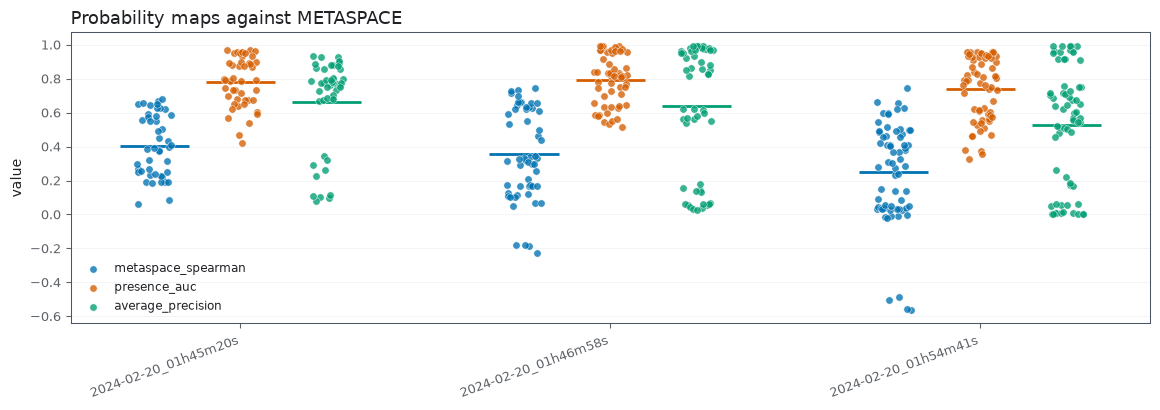

In [4]:
long = agreement.melt(id_vars=['dataset_id', 'repetition', 'class_name'], value_vars=['metaspace_spearman', 'presence_auc', 'average_precision'], var_name='statistic', value_name='value')
figures.repetition_points(long, value='value', group='dataset_id', hue='statistic', order=DATASETS, hue_order=['metaspace_spearman', 'presence_auc', 'average_precision'], colors={'metaspace_spearman': theme.model_palette[0], 'presence_auc': theme.model_palette[1], 'average_precision': theme.model_palette[2]}, ylabel='value', title='Probability maps against METASPACE', theme=theme);
display(mean_sd(table('image_summary'), ['dataset_id'], ['metaspace_spearman', 'presence_auc', 'average_precision']))

### Remarks

- Representative model, per-image medians: METASPACE Spearman 0.28-0.40, presence AUC 0.75-0.80, AP 0.62-0.86.

### Notes

## Relation between the two selection criteria

### Methodology

#### Theoretical

A class can have a high AP (annotated pixels ranked first) but a low METASPACE correlation (intensity pattern
not reproduced), or vice versa. Their relation is shown per image-class pair.

#### Implementation

Repetition means per image-class pair.

#### Figure descriptions

x = METASPACE Spearman, y = per-image AP; colour = class set. The table lists the selection.

,criterion,kind,rank,ion_index,dataset_id,class_name,mz,class_set,head_column,value
0,metaspace_spearman,best,0,19,2024-02-20_01h46m58s,C49H86O13P2|-H,943.5471,extension,485,0.7133
1,metaspace_spearman,best,1,17,2024-02-20_01h46m58s,C19H34O12|-H,453.1978,common,156,0.6656
2,metaspace_spearman,best,2,6,2024-02-20_01h45m20s,C47H79O12P|-H,865.5236,common,451,0.6591
3,metaspace_spearman,worst,0,26,2024-02-20_01h54m41s,C41H73O8P|-H,723.4970,common,349,-0.0119
4,metaspace_spearman,worst,1,33,2024-02-20_01h54m41s,C40H73N2O7P|-H,723.5083,common,340,0.0252
5,metaspace_spearman,worst,2,27,2024-02-20_01h54m41s,C39H78NO8P|-H,718.5392,common,335,0.0429
6,average_precision,best,0,19,2024-02-20_01h46m58s,C49H86O13P2|-H,943.5471,extension,485,0.9952
7,average_precision,best,1,22,2024-02-20_01h54m41s,C12H8O4|-H,215.0350,common,39,0.9922
8,average_precision,best,2,16,2024-02-20_01h46m58s,C47H79O12P|-H,865.5236,common,451,0.9736
9,average_precision,worst,0,26,2024-02-20_01h54m41s,C41H73O8P|-H,723.4970,common,349,0.0074


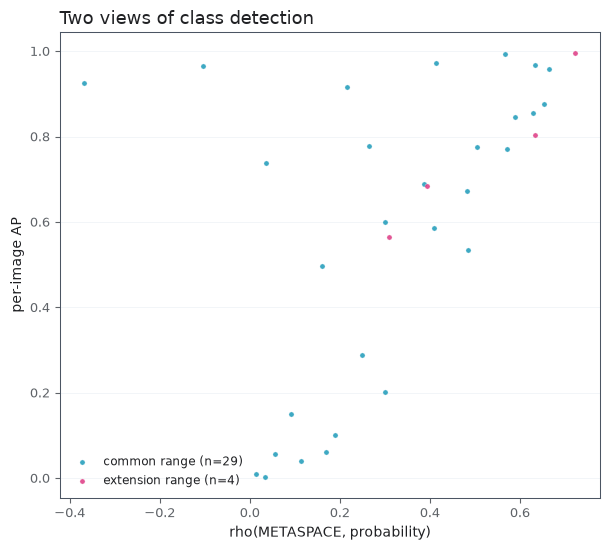

In [5]:
pairs = agreement.groupby(['dataset_id', 'class_name', 'class_set'], as_index=False)[['metaspace_spearman', 'average_precision', 'presence_auc']].mean()
sets = [value for value in figures.CLASS_SET_ORDER if value in set(pairs.class_set)]
figures.paired_scatter(pairs, x='metaspace_spearman', y='average_precision', hue='class_set', hue_order=sets, xlabel='rho(METASPACE, probability)', ylabel='per-image AP', title='Two views of class detection', diagonal=False, theme=theme);
display(selection.drop_duplicates(['criterion', 'dataset_id', 'class_name']))

### Remarks

- The extension class C49H86O13P2|-H (943.5) is the best class by both criteria (Spearman 0.71, AP 0.995); worst by both are sparse classes around 718-724 m/z (C41H73O8P|-H, C40H73N2O7P|-H, C39H78NO8P|-H) and C12H21N7O3|[M]-.

### Notes

## METASPACE, input, reconstruction and probability of the selected classes

### Methodology

#### Theoretical

The side-by-side images show directly whether the model finds the molecule where METASPACE finds it: METASPACE
intensity, the binary annotation target derived from it, input ion image, reconstructed ion image and head
probability. The probability has to be read against the target, not against the intensity.

#### Implementation

`ion_pixels`: METASPACE intensity, target, input ion, reconstructed ion and probability of the representative model.

#### Figure descriptions

Rows = selected image-class pairs (criterion, best/worst), columns = METASPACE intensity, annotation target
(METASPACE > 0), input ion, reconstructed ion, probability. Every panel has its own colour range; the METASPACE
and target ranges are taken over their positive pixels, so ions present in few pixels stay visible.

average_precision


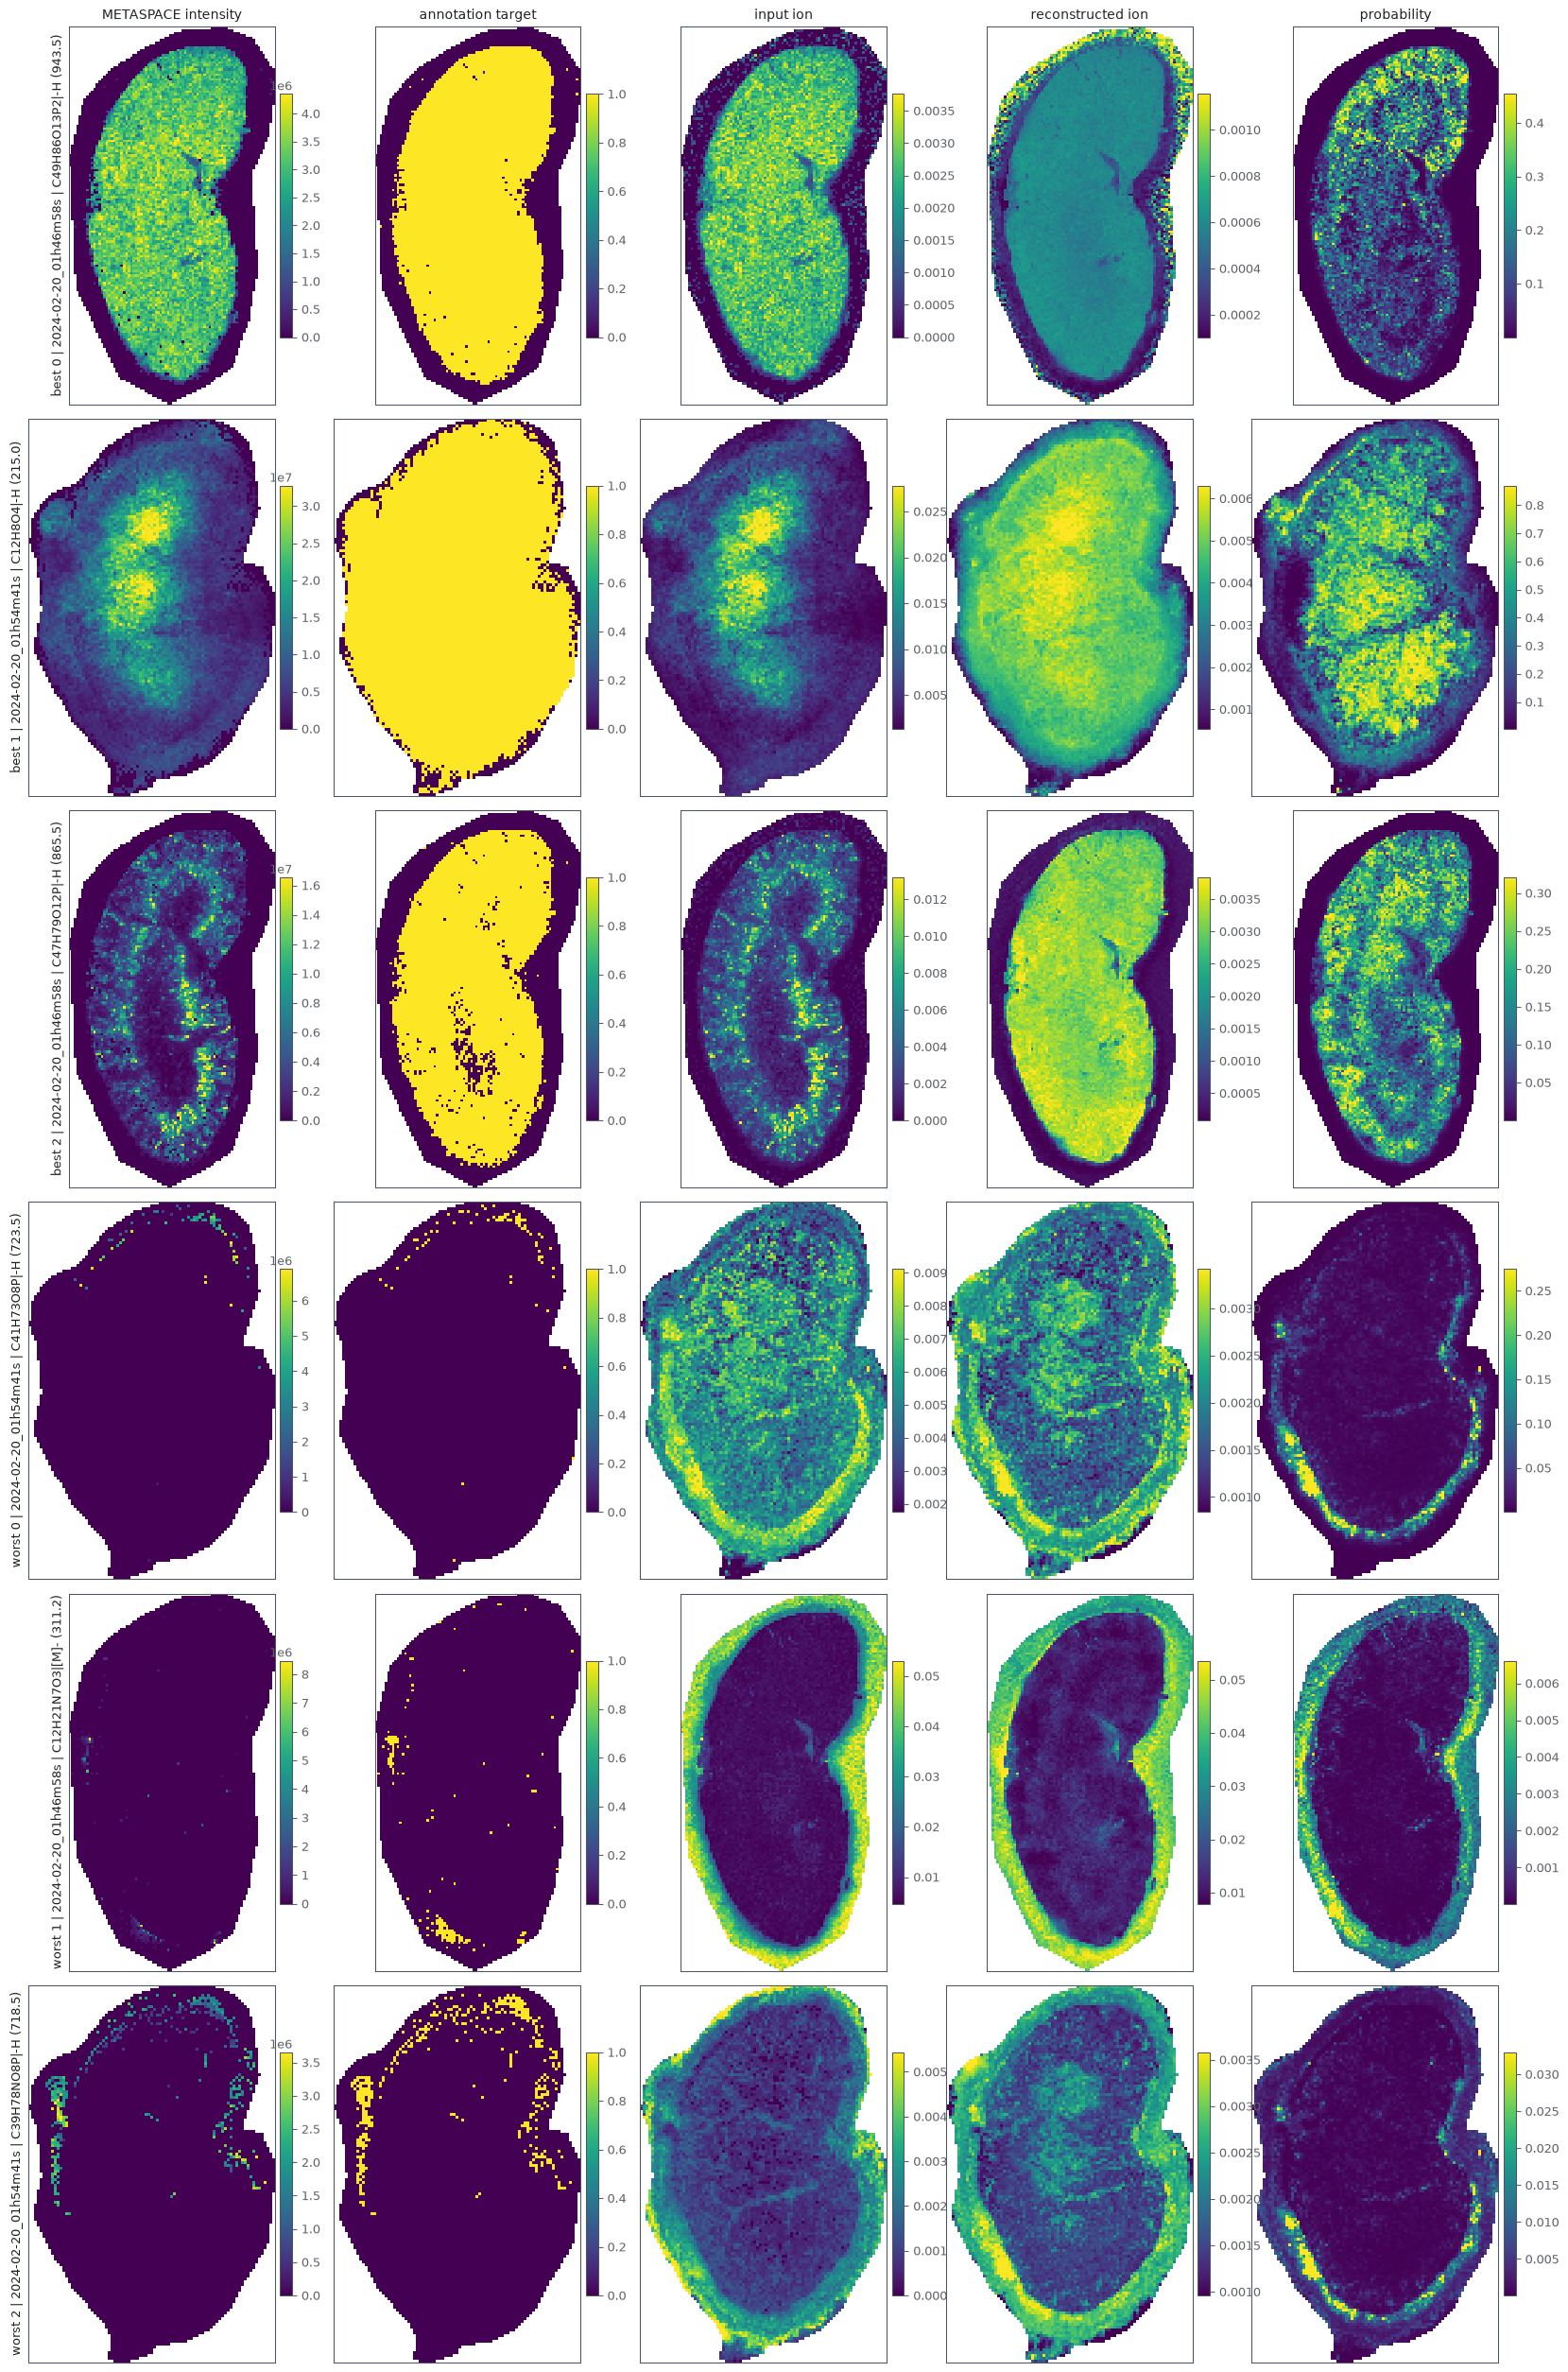

metaspace_spearman


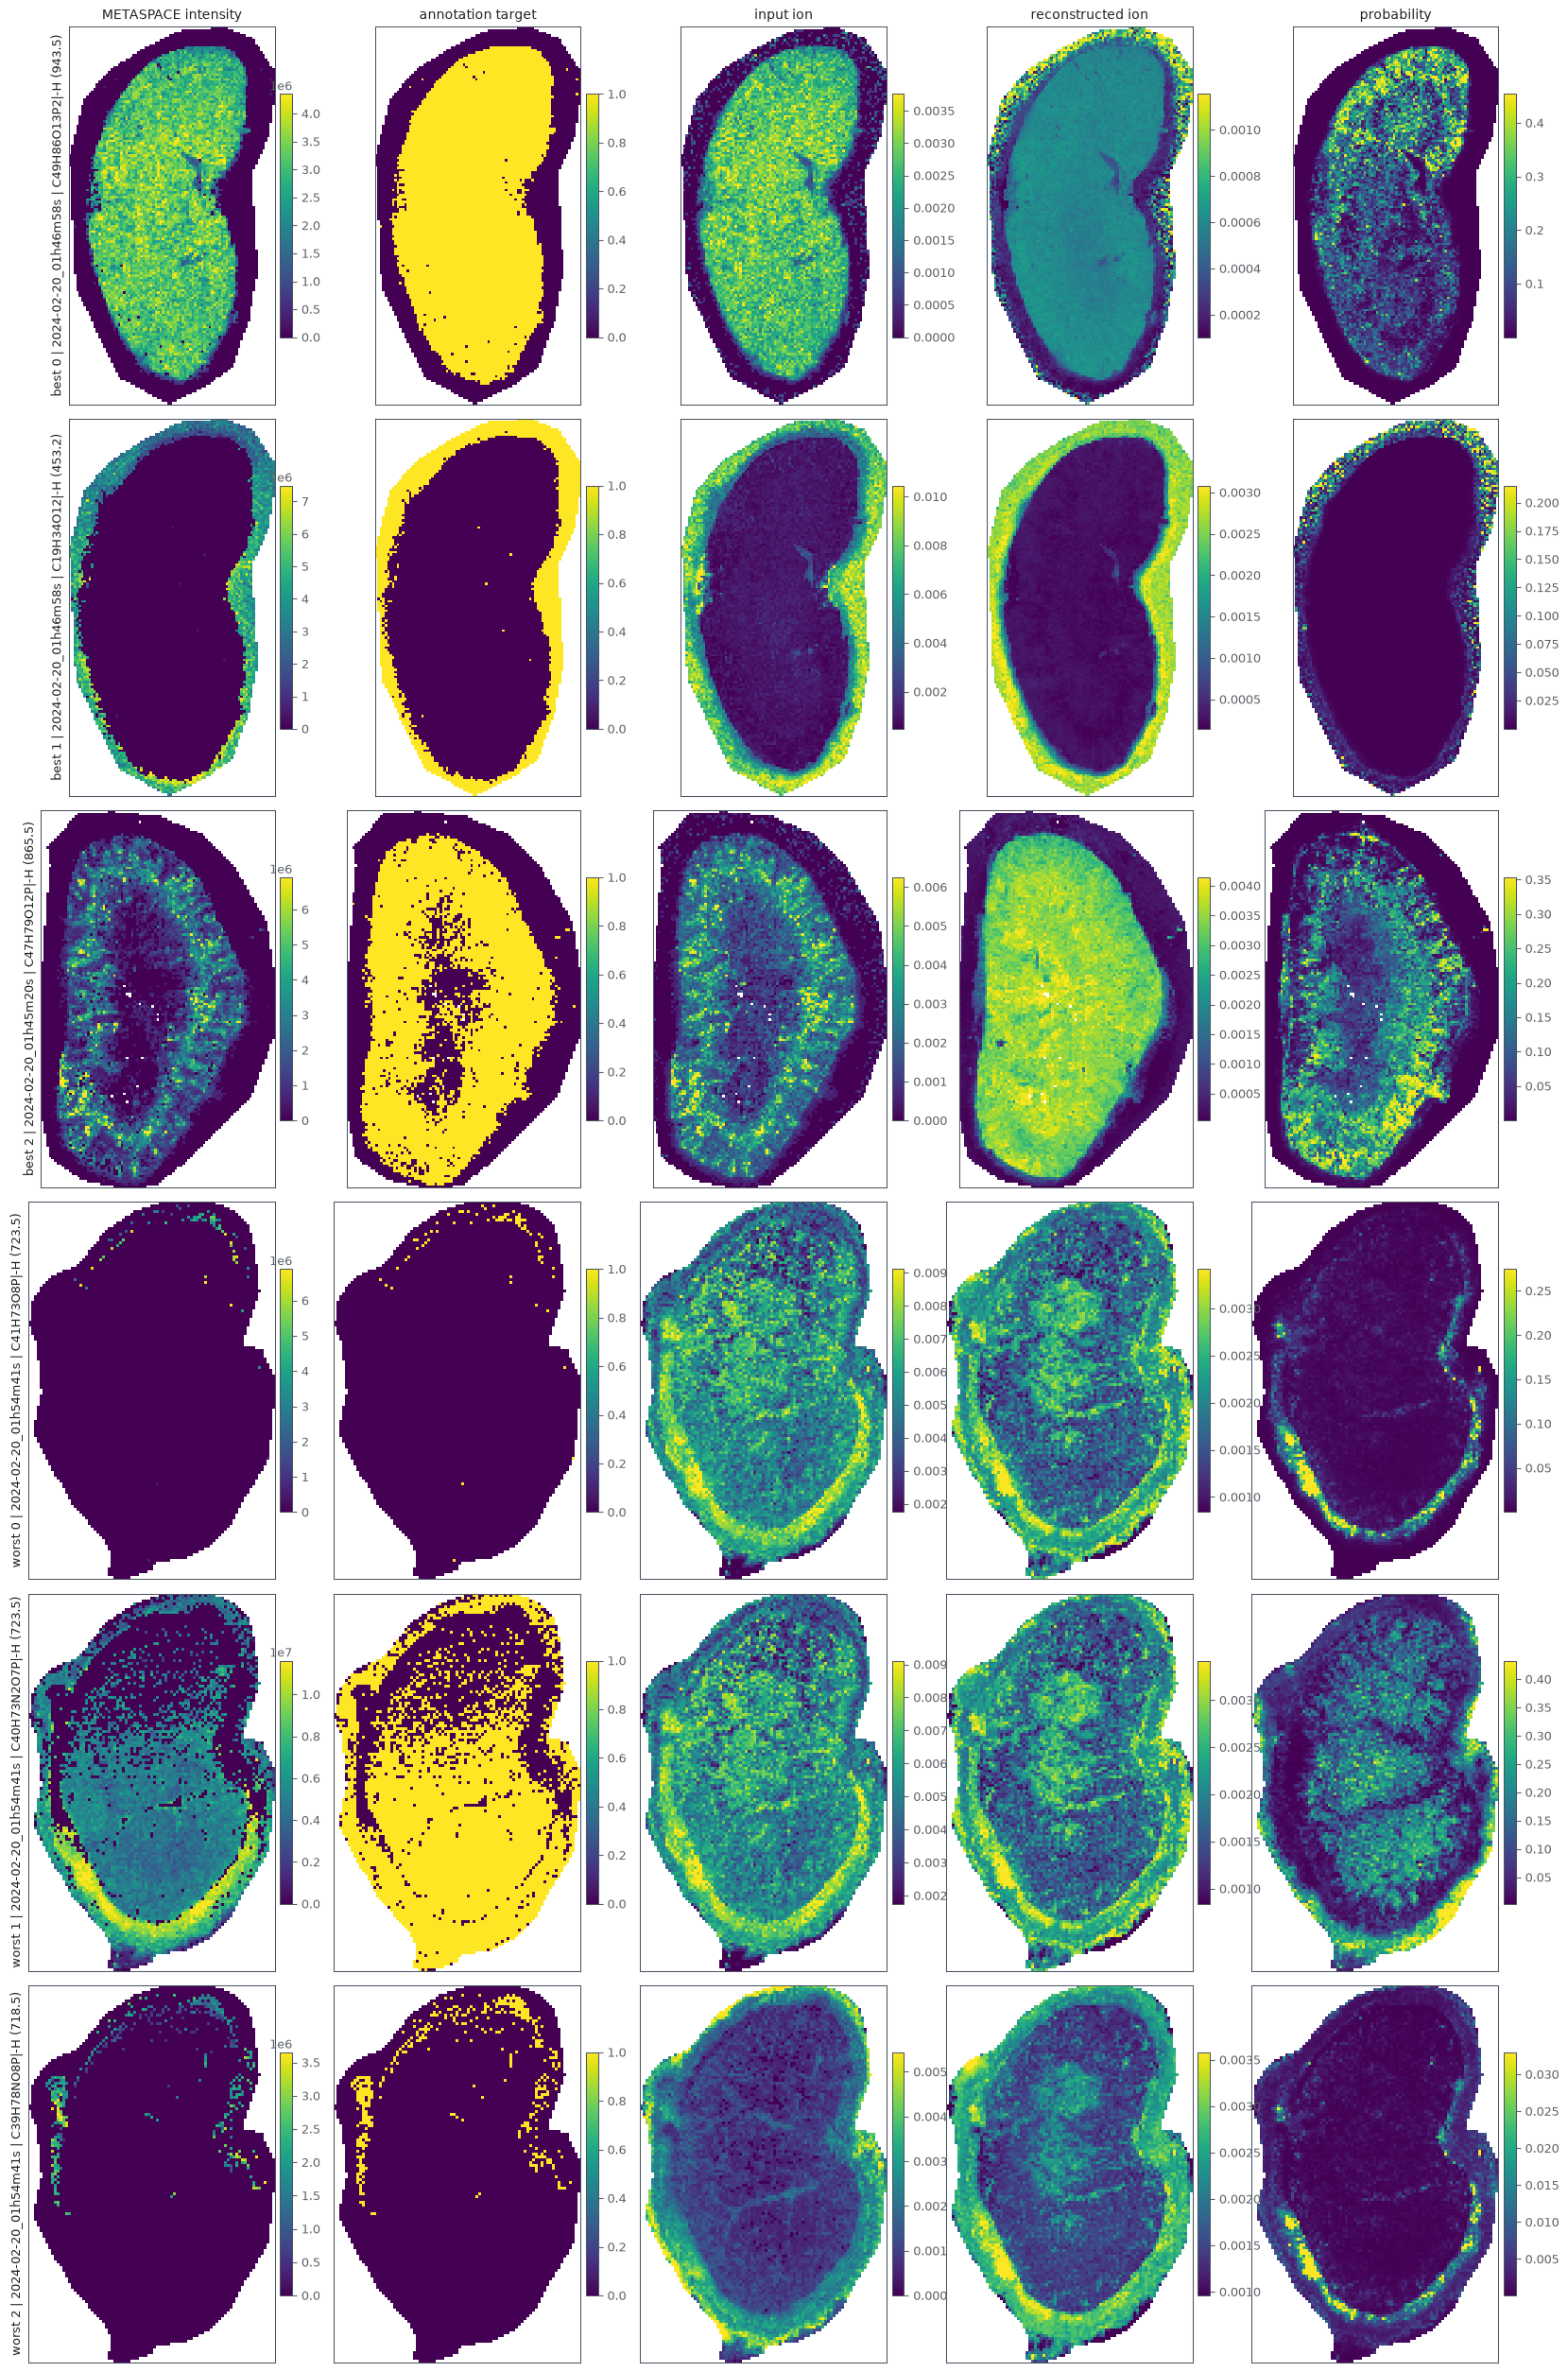

In [6]:
ion_pixels = table('ion_pixels')
for criterion, chosen in selection.drop_duplicates(['criterion', 'dataset_id', 'class_name']).groupby('criterion'):
    panel = ion_pixels.merge(chosen[['dataset_id', 'class_name', 'kind', 'rank', 'value']], on=['dataset_id', 'class_name'])
    panel['panel'] = panel.kind + ' ' + panel['rank'].astype(str) + ' | ' + panel.dataset_id + ' | ' + panel.class_name + ' (' + panel.mz.round(1).astype(str) + ')'
    rows = list(dict.fromkeys(panel.sort_values(['kind', 'rank']).panel))
    print(criterion)
    figures.image_panels(panel, value_columns=['metaspace', 'target', 'input_ion', 'output_ion', 'probability'], column_titles=['METASPACE intensity', 'annotation target', 'input ion', 'reconstructed ion', 'probability'], datasets=rows, row_column='panel', shared_scale='panel', positive_columns=['metaspace', 'target'], cmap=theme.probability_colormap, theme=theme)
    plt.show()

### Remarks

- C49H86O13P2|-H: probability 0.14 on target versus 0.002 elsewhere: an almost perfect ranking at a low level, the reason for the near-zero extension recall in `part_1_10`.
- C12H8O4|-H (target on 91 % of the tissue): 0.41 on target versus 0.06 elsewhere.

### Notes

## Results / Summary

### LLM

- **Observed:** as on the narrow axis, probability maps rank annotated pixels correctly (presence AUC 0.75-0.80) at low absolute probabilities; an extension class is the best-detected class of the axis.
- **Interpretation:** the wide head learns the extension classes; their use on new images requires calibration of the threshold, not more capacity.

### Person